Total NO2 samples: 419509
a_r = 0.15000000000000002
b_r = 1.2

Learned (Raw) Parameters:
lambda = 0.0021053385101303707
mu = 19.798425613563772
c = 0.026948181261027937

After Normalization (Valid PDF):
lambda = 0.0021053385101303707
mu = 19.798425613563772
c_normalized = 0.025887256740295014
Area check (should be 1): 0.9999999999999999


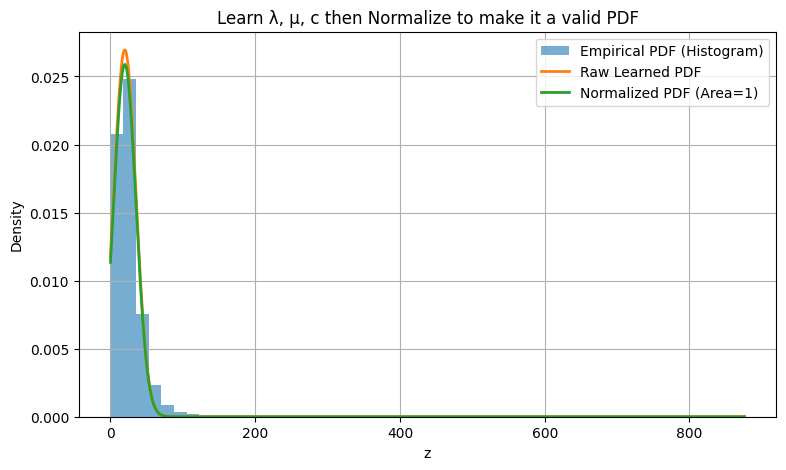

MSE (normalized fit): 1.0766215281417951e-07
KL Divergence (normalized fit): 0.19871606026540986

FINAL VALUES TO SUBMIT (Valid PDF):
λ = 0.002105
μ = 19.798426
c = 0.025887


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

df = pd.read_csv(
    "/kaggle/input/india-air-quality-data/data.csv",
    encoding="latin1",
    usecols=["no2"],
    low_memory=False
)

x = pd.to_numeric(df["no2"], errors="coerce").dropna().values
print("Total NO2 samples:", len(x))

r = 102303918
a_r = 0.05 * (r % 7)
b_r = 0.3 * ((r % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)

z = x + a_r * np.sin(b_r * x)

bins = 50
hist_vals, bin_edges = np.histogram(z, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
dz = bin_edges[1] - bin_edges[0]

def pdf_model(z_val, lam, mu, c):
    return c * np.exp(-lam * (z_val - mu) ** 2)

initial_guess = [1.0 / (2.0 * np.var(z, ddof=0)), np.mean(z), 0.02]

params, covariance = curve_fit(
    pdf_model,
    bin_centers,
    hist_vals,
    p0=initial_guess,
    bounds=([1e-12, -np.inf, 1e-12], [np.inf, np.inf, np.inf])
)

lam_fit, mu_fit, c_fit = params

print("\nLearned (Raw) Parameters:")
print("lambda =", lam_fit)
print("mu =", mu_fit)
print("c =", c_fit)

area_inf = c_fit * np.sqrt(np.pi / lam_fit)
c_norm = c_fit / area_inf

print("\nAfter Normalization (Valid PDF):")
print("lambda =", lam_fit)
print("mu =", mu_fit)
print("c_normalized =", c_norm)
print("Area check (should be 1):", c_norm * np.sqrt(np.pi / lam_fit))

z_range = np.linspace(z.min(), z.max(), 1000)
pdf_raw = pdf_model(z_range, lam_fit, mu_fit, c_fit)
pdf_norm = pdf_model(z_range, lam_fit, mu_fit, c_norm)

plt.figure(figsize=(9, 5))
plt.hist(z, bins=bins, density=True, alpha=0.6, label="Empirical PDF (Histogram)")
plt.plot(z_range, pdf_raw, linewidth=2, label="Raw Learned PDF")
plt.plot(z_range, pdf_norm, linewidth=2, label="Normalized PDF (Area=1)")
plt.xlabel("z")
plt.ylabel("Density")
plt.title("Learn λ, μ, c then Normalize to make it a valid PDF")
plt.legend()
plt.grid(True)
plt.show()

predicted_pdf = pdf_model(bin_centers, lam_fit, mu_fit, c_norm)

mse = mean_squared_error(hist_vals, predicted_pdf)
print("MSE (normalized fit):", mse)

epsilon = 1e-12
P = hist_vals + epsilon
Q = predicted_pdf + epsilon

P = P / (np.sum(P) * dz)
Q = Q / (np.sum(Q) * dz)

kl_div = np.sum(P * np.log(P / Q)) * dz
print("KL Divergence (normalized fit):", kl_div)

print("\nFINAL VALUES TO SUBMIT (Valid PDF):")
print(f"λ = {lam_fit:.6f}")
print(f"μ = {mu_fit:.6f}")
print(f"c = {c_norm:.6f}")
